# import

In [1]:
import torch
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import torch.nn as nn
import torch.optim as optim
!pip install torchinfo
from torchinfo import summary
from torchvision import models

import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm


# 乱数の固定

In [2]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms = True


# （可能なら）GPUの利用

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)


cuda:0


# 汎用関数の定義

## func show_images_labels

In [4]:
# イメージとラベル表示
def show_images_labels(loader, classes, net, device):
    # データローダーから最初の1セットを取得する
    for images, labels in loader:
        break
    # 表示数は50個とバッチサイズのうち小さい方
    n_size = min(images.size(0), 50)

    if net is not None:
        # デバイスの割り当て
        inputs = images.to(device)
        labels = labels.to(device)

      # 予測計算
        outputs = net(inputs)
        predicted = torch.max(outputs,1)[1]
        #images = images.to('cpu')

    # 最初のn_size個の表示
    plt.figure(figsize=(20, 15))
    for i in range(n_size):
        ax = plt.subplot(5, 10, i + 1)
        label_name = classes[labels[i]]
        # netがNoneでない場合は、予測結果もタイトルに表示する
        if net is not None:
            predicted_name = classes[predicted[i]]
            # 正解かどうかで色分けをする
            if label_name == predicted_name:
                c = 'g'
            else:
                c = 'r'
            ax.set_title(label_name + ':' + predicted_name, c=c, fontsize=20)
        # netがNoneの場合は、正解ラベルのみ表示
        else:
            ax.set_title(label_name, fontsize=20)
        # TensorをNumPyに変換
        image_np = images[i].numpy().copy()
        #print(image_np.shape)
        # 軸の順番変更 (channel, row, column) -> (row, column, channel)
        img = np.transpose(image_np, (1, 2, 0))
        # 値の範囲を[-1, 1] -> [0, 1]に戻す
        img = (img + 1)/2
        # 結果表示
        plt.imshow(img)
        ax.set_axis_off()
    plt.show()


## func evaluate_history

In [5]:
def evaluate_history(history):
    print(f'初期状態: valid_loss: {history[0, 3]:.5f} valid_acc: {history[0, 4]:.5f}') 
    print(f'最終状態: valid_loss: {history[-1, 3]:.5f} valid_acc: {history[-1, 4]:.5f}' )

    num_epochs = len(history)
    unit = num_epochs / 10

    plt.figure(figsize=(9, 8))
    plt.plot(history[:, 0], history[:, 1], 'r', label='train')
    plt.plot(history[:, 0], history[:, 3], 'b', label='valid')
    plt.xticks(np.arange(0, num_epochs + 1, unit))
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title('Learning Curve (Loss)')
    plt.grid()
    plt.legend()
    plt.show()

    plt.figure(figsize=(9,8))
    plt.plot(history[:, 0], history[:, 2], 'r', label='train')
    plt.plot(history[:, 0], history[:, 4], 'b', label='valid')
    plt.xticks(np.arange(0, num_epochs + 1, unit))
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Learning Curve (Accuracy)')
    plt.grid()
    plt.legend()
    plt.show()


## func fit

In [6]:
def fit(num_epochs, net, criterion, optimizer, train_loader, valid_loader, device, history):
    pbar = tqdm(range(num_epochs), desc="Total Epochs", leave=True)

    for epoch in pbar:
        train_loss, train_acc, n_train = 0, 0, 0
        valid_loss, valid_acc, n_valid = 0, 0, 0

        # 訓練フェーズ
        net.train()
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Train", leave=False):
            batch_size = images.size(0)
            n_train += batch_size

            inputs = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad() # 勾配の初期化
            outputs = net(inputs) # 予測計算
            loss = criterion(outputs, labels) # 損失計算
            loss.backward() # 勾配計算
            optimizer.step() # パラメータ更新

            train_loss += loss.item() * batch_size # 損失はバッチサイズで平均されているため戻しておく．
            _, indices = torch.max(outputs, dim=1)
            train_acc += (indices == labels).sum().item()

        # 検証フェーズ
        net.eval()
        with torch.no_grad():
            for images, labels in valid_loader:
                batch_size = images.size(0)
                n_valid += batch_size

                inputs = images.to(device)
                labels = labels.to(device)

                outputs = net(inputs) # 予測計算
                loss = criterion(outputs, labels) # 損失計算

                valid_loss += loss.item() * batch_size # 損失はバッチサイズで平均されているため戻しておく．
                _, indices = torch.max(outputs, dim=1)
                valid_acc += (indices == labels).sum().item()

        # 記録フェーズ
        train_loss /= n_train
        train_acc /= n_train

        valid_loss /= n_valid
        valid_acc /= n_valid

        pbar.set_postfix({
            'train_loss': f"{train_loss:.4f}",
            'train_acc': f"{train_acc:.4f}",
            'valid_loss': f"{valid_loss:.4f}",
            'valid_acc': f"{valid_acc:.4f}"
        })

        item = np.array([epoch, train_loss, train_acc, valid_loss, valid_acc])
        history = np.vstack((history, item))
    
    return history


# データ準備

## Transformsの定義

In [7]:
train_transform = transforms.Compose([
    transforms.Resize(112),
    transforms.RandomHorizontalFlip(p=0.5), # PIL画像の処理なのでテンソル化の前
    transforms.ToTensor(),
    transforms.Normalize(0.5, 0.5),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3), value=0, inplace=False) # 一部を黒く塗りつぶし
])

eval_transform = transforms.Compose([
    transforms.Resize(112),
    transforms.ToTensor(),
    transforms.Normalize(0.5, 0.5)
])


## データセットの定義

In [8]:
data_root = './data'

# 元になるデータセット
train_set_full = datasets.CIFAR10(root=data_root, train=True, download=True, transform=train_transform)
valid_set_full = datasets.CIFAR10(root=data_root, train=True, download=True, transform=eval_transform)

train_size = int(len(train_set_full) * 0.9)

# データを分割するためのランダムなインデックスを生成
indices = torch.randperm(len(train_set_full)).tolist()

train_set = Subset(train_set_full, indices[:train_size])
valid_set = Subset(valid_set_full, indices[train_size:])
test_set = datasets.CIFAR10(root=data_root, train=False, download=True, transform=eval_transform)

print(len(train_set))
print(len(valid_set))
print(len(test_set))


100%|██████████| 170M/170M [00:18<00:00, 9.15MB/s] 


45000
5000
10000


## データローダーの定義

In [9]:
# from torch.utils.data import Dataloader

train_loader = DataLoader(train_set, batch_size=64, shuffle=True) # 小さめのバッチサイズで過学習の防止を期待する．
valid_loader = DataLoader(valid_set, batch_size=128, shuffle=False)
test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

# データローダーから先頭のミニバッチを取得してみる．
for loader in [train_loader, valid_loader, test_loader]:
    for images, labels in loader:
        print(f"images.shape: {images.shape}, labels.shape: {labels.shape}")
        break


images.shape: torch.Size([64, 3, 112, 112]), labels.shape: torch.Size([64])
images.shape: torch.Size([128, 3, 112, 112]), labels.shape: torch.Size([128])
images.shape: torch.Size([128, 3, 112, 112]), labels.shape: torch.Size([128])


## 正解ラベルの変換規則

In [10]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


## 最初の50個の表示

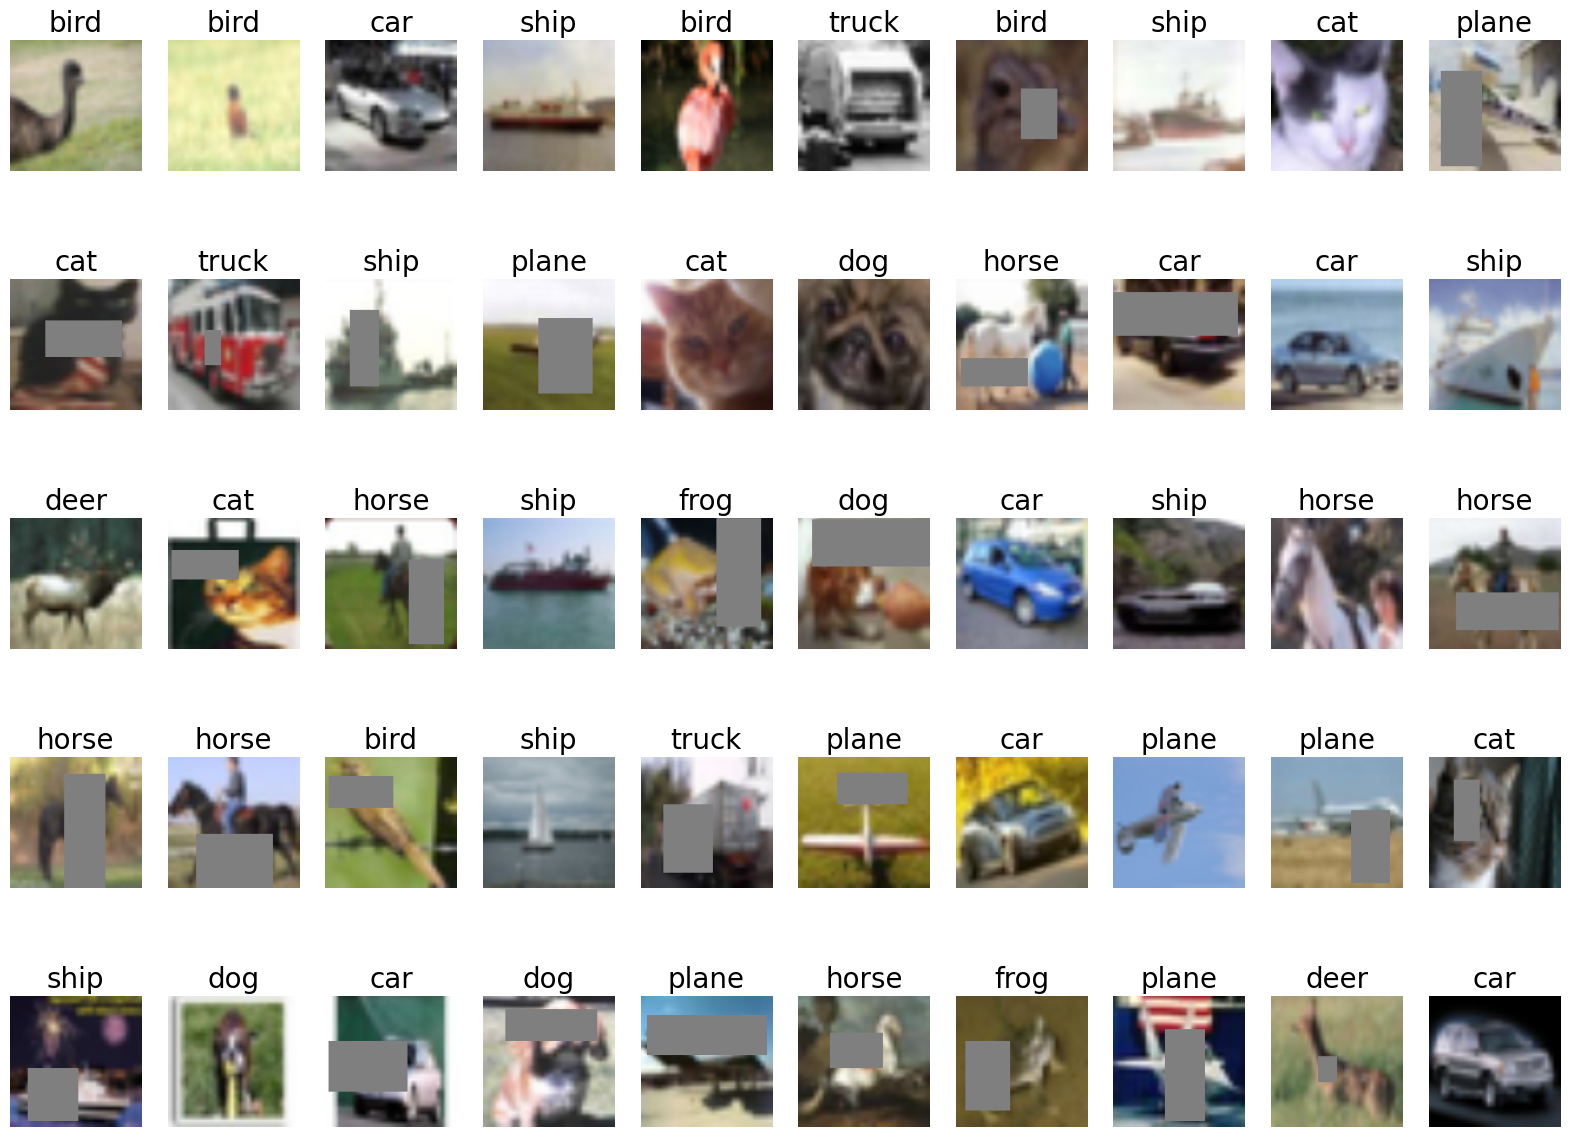

In [11]:
show_images_labels(train_loader, classes, None, None)


# 転移学習

## ResNet-18

### モデルの読み込み

In [67]:
net = models.resnet18(pretrained=True)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### モデル構造の確認
全結合層の変数名は，`fc`である事がわかる．

In [68]:
print(net)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [69]:
net = net.to(device)
summary(net, (100,3,112,112))


Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [100, 1000]               --
├─Conv2d: 1-1                            [100, 64, 56, 56]         9,408
├─BatchNorm2d: 1-2                       [100, 64, 56, 56]         128
├─ReLU: 1-3                              [100, 64, 56, 56]         --
├─MaxPool2d: 1-4                         [100, 64, 28, 28]         --
├─Sequential: 1-5                        [100, 64, 28, 28]         --
│    └─BasicBlock: 2-1                   [100, 64, 28, 28]         --
│    │    └─Conv2d: 3-1                  [100, 64, 28, 28]         36,864
│    │    └─BatchNorm2d: 3-2             [100, 64, 28, 28]         128
│    │    └─ReLU: 3-3                    [100, 64, 28, 28]         --
│    │    └─Conv2d: 3-4                  [100, 64, 28, 28]         36,864
│    │    └─BatchNorm2d: 3-5             [100, 64, 28, 28]         128
│    │    └─ReLU: 3-6                    [100, 64, 28, 28]         --
│

### 全結合層の付け替え

In [70]:
fc_in_features = net.fc.in_features
net.fc = nn.Linear(fc_in_features, len(classes))

print(net) # ちゃんと確認しようね．


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### 学習の初期設定

In [71]:
num_epochs = 5

net = models.resnet18(pretrained=True)
fc_in_features = net.fc.in_features
net.fc = nn.Linear(fc_in_features, len(classes))
net = net.to(device) # 忘れずにGPUに送ってください．

criterion = nn.CrossEntropyLoss()

lr = 0.001
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

history = np.zeros((0, 5))


### 学習ループ

In [72]:
history = fit(num_epochs, net, criterion, optimizer, train_loader, valid_loader, device, history)


Total Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1 Train:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 2 Train:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 3 Train:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 4 Train:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 5 Train:   0%|          | 0/704 [00:00<?, ?it/s]

### 評価

初期状態: valid_loss: 0.25969 valid_acc: 0.91200
最終状態: valid_loss: 0.17674 valid_acc: 0.93900


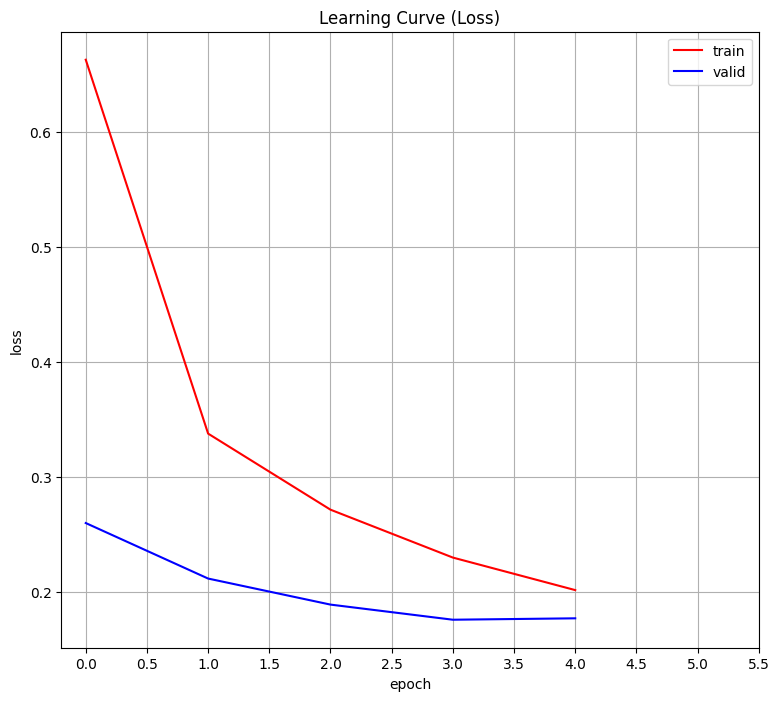

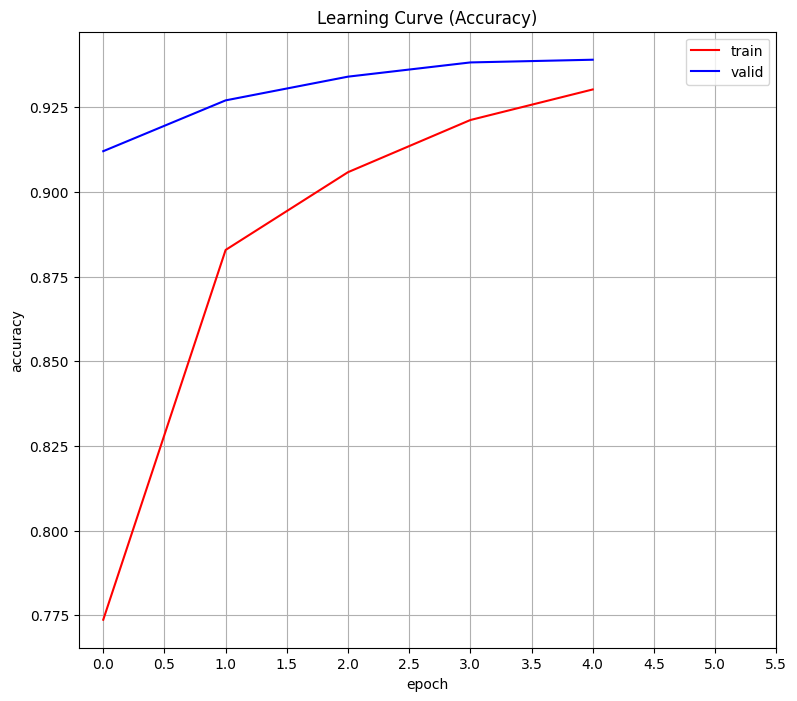

In [73]:
evaluate_history(history)


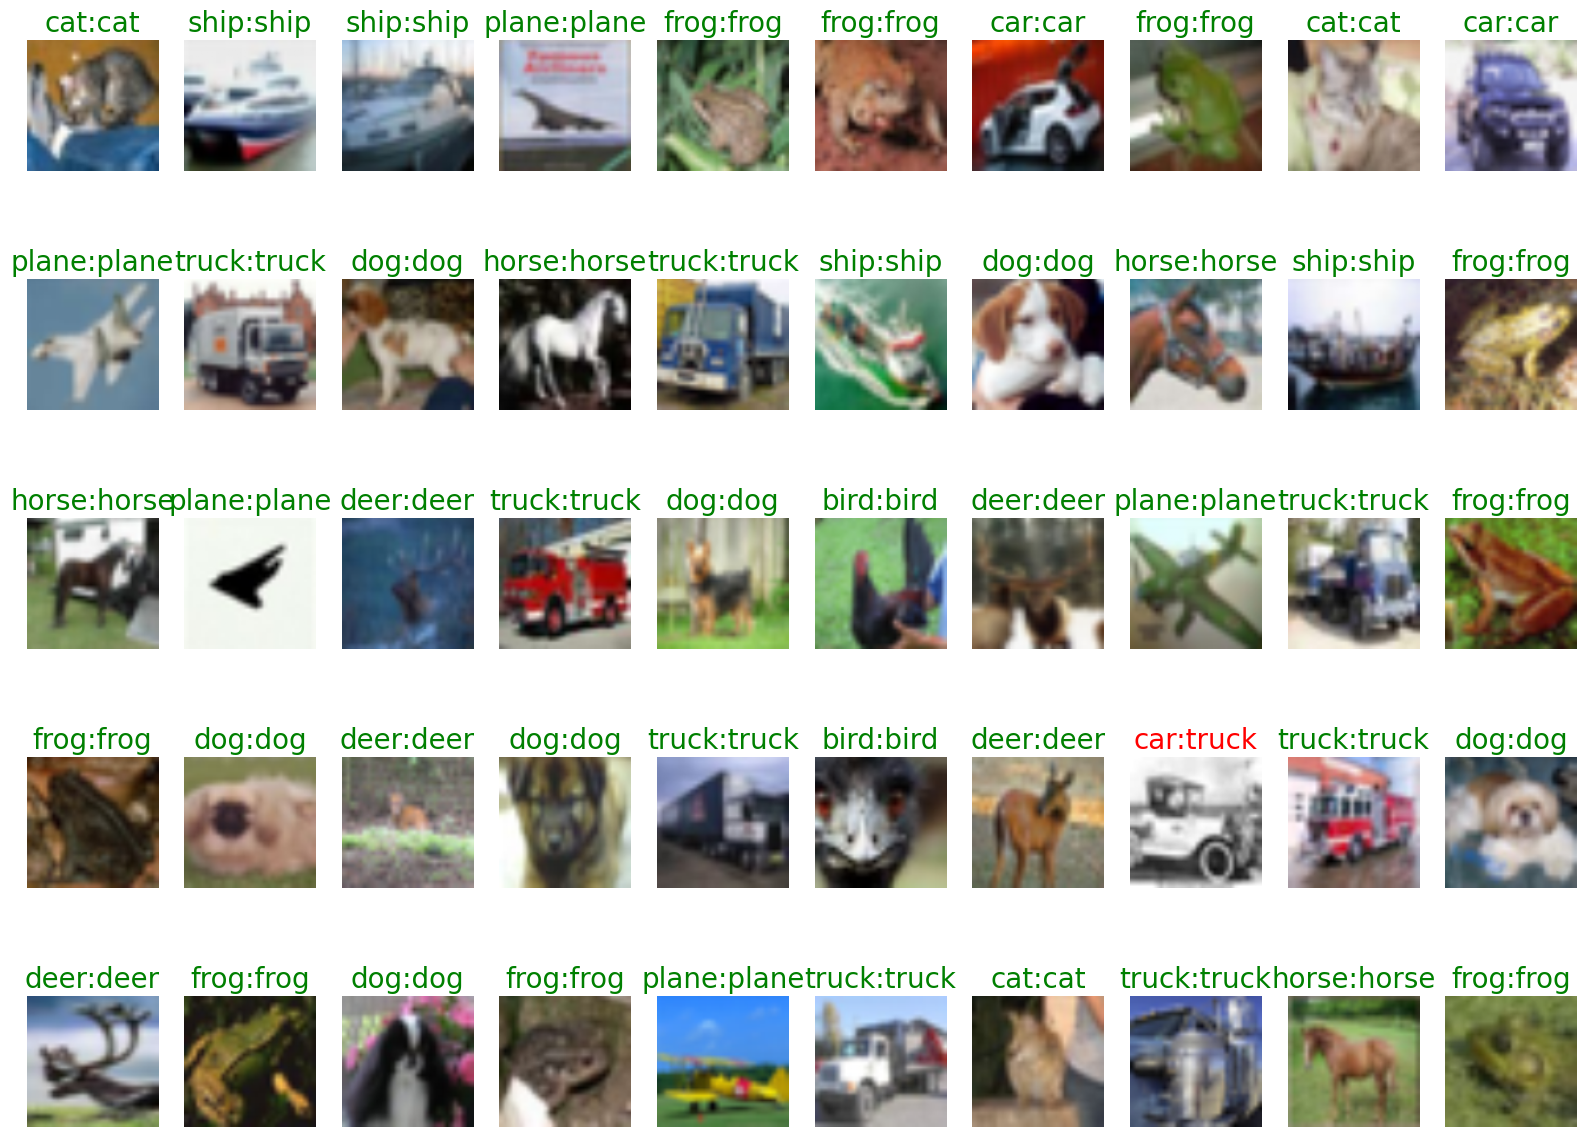

In [74]:
show_images_labels(test_loader, classes, net, device)


## VGG-19-BN

### モデルの読み込み

In [12]:
net = models.vgg19_bn(pretrained=True)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth" to /root/.cache/torch/hub/checkpoints/vgg19_bn-c79401a0.pth


100%|██████████| 548M/548M [00:03<00:00, 169MB/s] 


### モデル構造の確認
全結合層の変数名は，`classifier[6]`である事がわかる．

In [13]:
print(net)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256

### 学習の初期設定

In [14]:
num_epochs = 5

net = models.vgg19_bn(pretrained=True)
in_features = net.classifier[6].in_features
net.classifier[6] = nn.Linear(in_features, len(classes))
net = net.to(device)

criterion = nn.CrossEntropyLoss()

lr = 0.001
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

history = np.zeros((0, 5))


### 学習ループ

In [15]:
history = fit(num_epochs, net, criterion, optimizer, train_loader, valid_loader, device, history)


Total Epochs:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1 Train:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 2 Train:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 3 Train:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 4 Train:   0%|          | 0/704 [00:00<?, ?it/s]

Epoch 5 Train:   0%|          | 0/704 [00:00<?, ?it/s]

### 評価

初期状態: valid_loss: 0.19467 valid_acc: 0.93400
最終状態: valid_loss: 0.12054 valid_acc: 0.95980


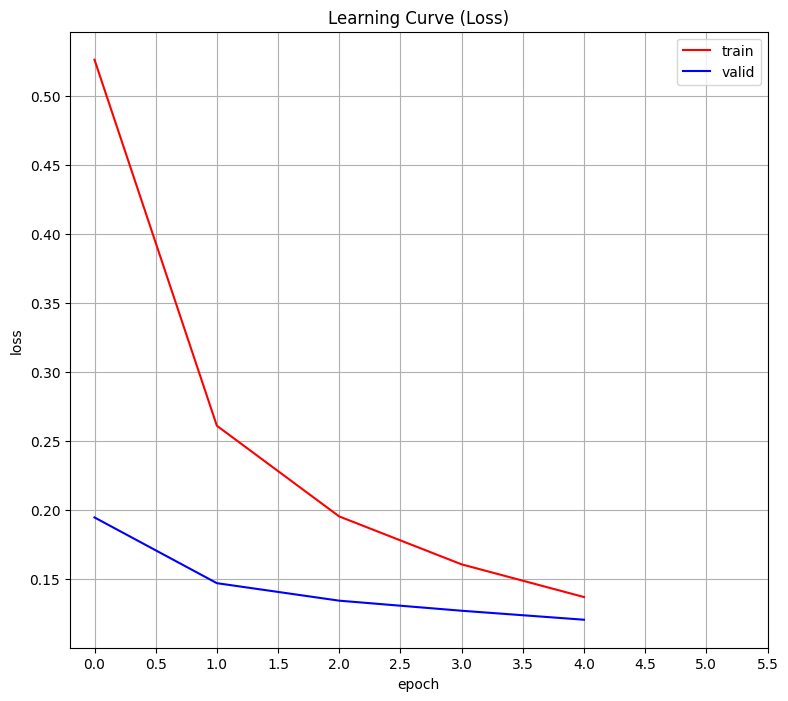

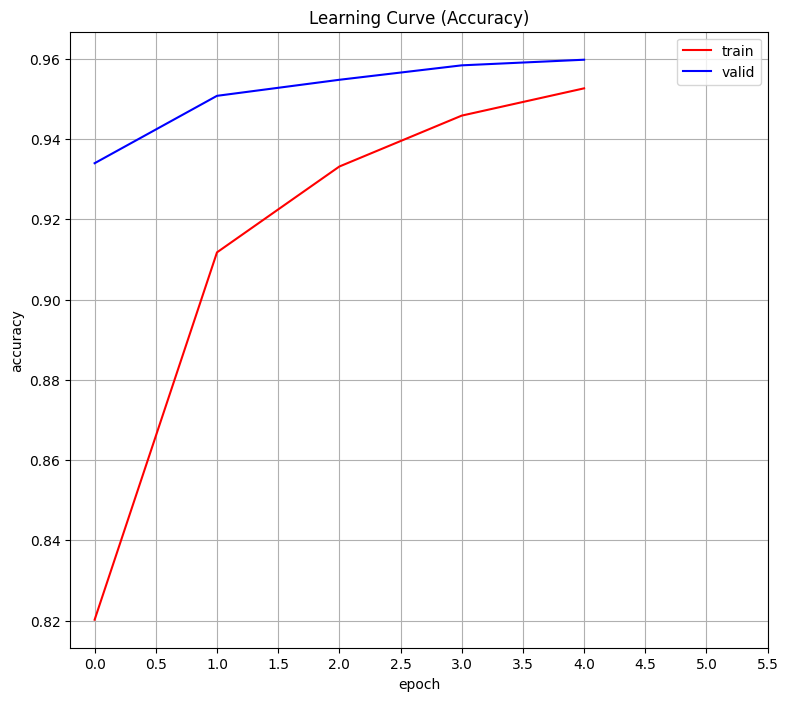

In [16]:
evaluate_history(history)


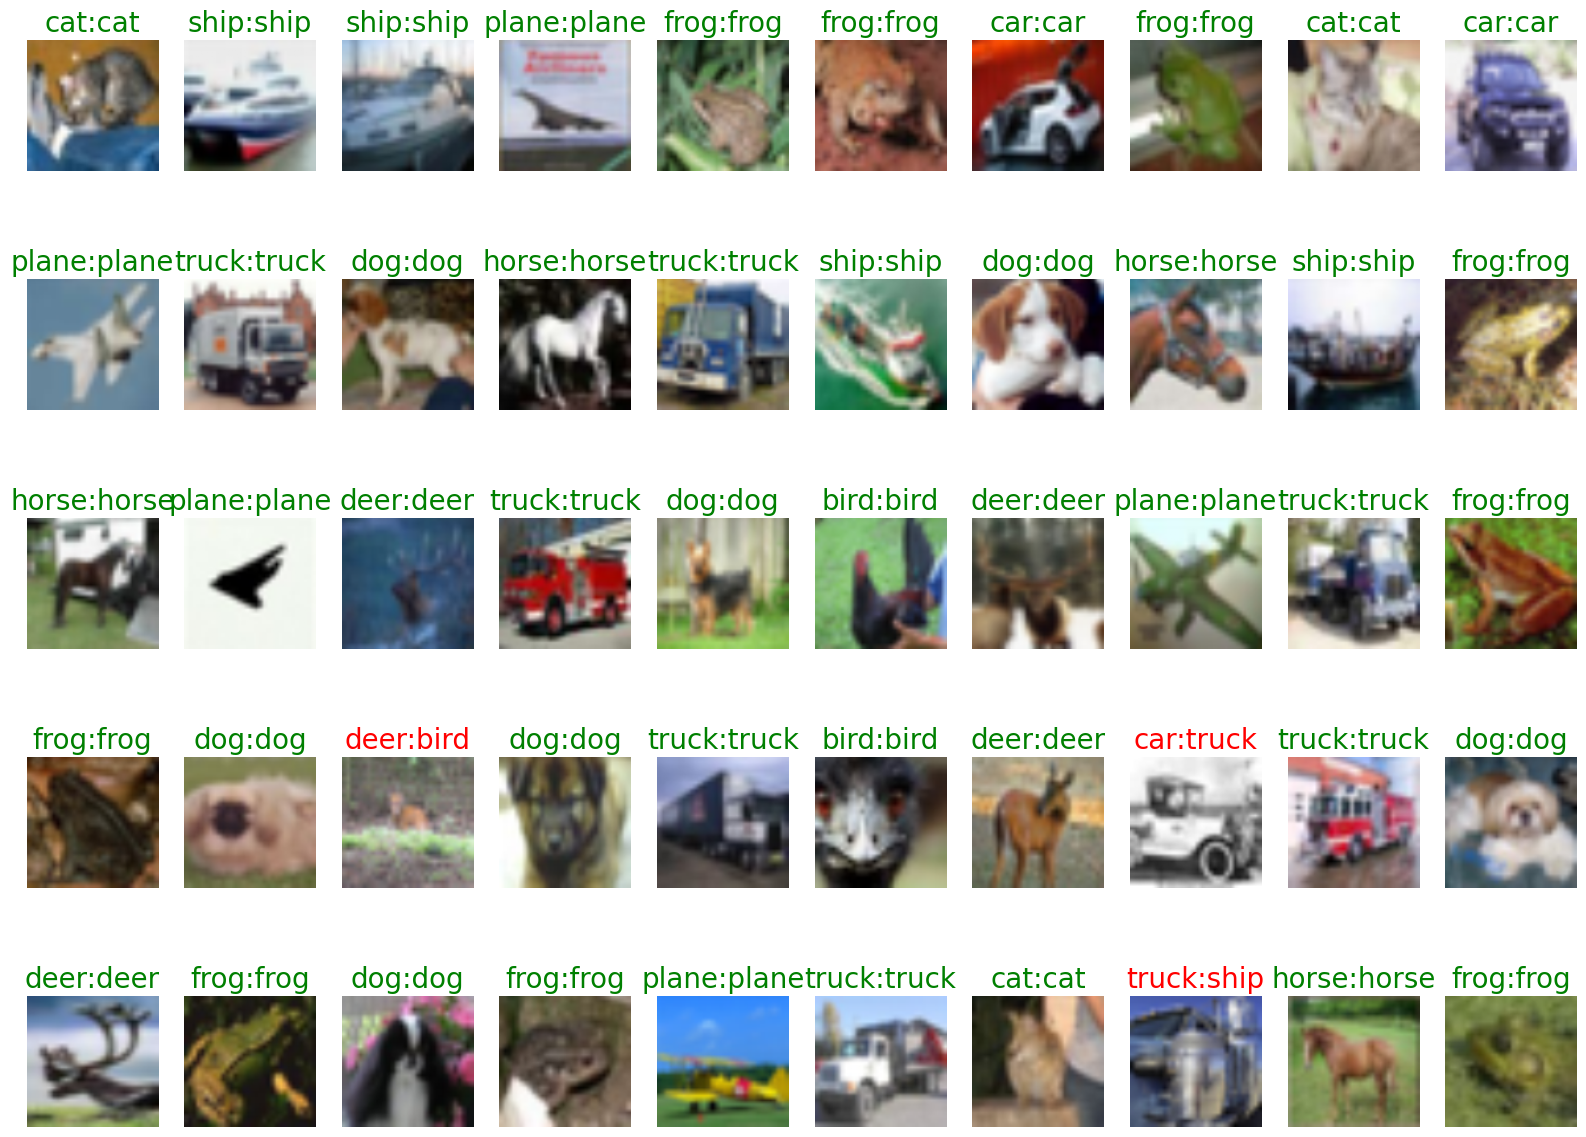

In [17]:
show_images_labels(test_loader, classes, net, device)
